# Compare the test results of ResNet and Vision Transformer

## Data Preparation

First get data from both csv-files into one dataframe 

In [1]:
import pandas as pd

RESNET_CSV = "model/resnet.csv"
VIT_CSV = "model/vit.csv"

resnet = pd.read_csv(RESNET_CSV)
vit = pd.read_csv(VIT_CSV)

resnet = resnet.rename(columns={
    "prediction": "pred_resnet",
})

In [2]:
df = resnet.copy()
df["pred_vit"] = vit["prediction"]

df.head()

,image,ground_truth,pred_resnet,pred_vit
0,0616.jpg,Romania,Romania,Spain
1,0735.jpg,Hong Kong,Hong Kong,Hong Kong
2,0012.jpg,Dominican Republic,Dominican Republic,Dominican Republic
3,0431.jpg,Romania,Croatia,Slovakia
4,0445.jpg,France,France,France


In [3]:
df["resnet_correct"] = df["pred_resnet"] == df["ground_truth"]
df["vit_correct"] = df["pred_vit"] == df["ground_truth"]

df["same_prediction"] = df["pred_resnet"] == df["pred_vit"]
df.head()

,image,ground_truth,pred_resnet,pred_vit,resnet_correct,vit_correct,same_prediction
0,0616.jpg,Romania,Romania,Spain,True,False,False
1,0735.jpg,Hong Kong,Hong Kong,Hong Kong,True,True,True
2,0012.jpg,Dominican Republic,Dominican Republic,Dominican Republic,True,True,True
3,0431.jpg,Romania,Croatia,Slovakia,False,False,False
4,0445.jpg,France,France,France,True,True,True


## Metrics over whole set

Calculate Accuracy for both models over whole set

-> ResNet is slightly better, but does not strictly tell that ResNet is the overall better model (randomness, ...)

In [4]:
acc_resnet = df["resnet_correct"].mean()
acc_vit = df["vit_correct"].mean()

print(f"ResNet accuracy: {acc_resnet:.3f}")
print(f"ViT accuracy: {acc_vit:.3f}")

ResNet accuracy: 0.716
ViT accuracy: 0.703


### Per class differences

Calculate the accuracy difference of both models per class

-> see which model performs better for which class

In [5]:
per_class = (
    df.groupby("ground_truth")
      .agg(
          resnet_acc=("resnet_correct", "mean"),
          vit_acc=("vit_correct", "mean"),
          samples=("ground_truth", "count")
      )
      .reset_index()
)

per_class["abs_diff"] = (per_class["resnet_acc"] - per_class["vit_acc"]).abs()

per_class.sort_values("abs_diff")
per_class.head()

,ground_truth,resnet_acc,vit_acc,samples,abs_diff
0,Albania,0.693069,0.643564,101,0.049505
1,American Samoa,0.950000,0.880000,100,0.070000
2,Andorra,0.970000,0.940000,100,0.030000
3,Argentina,0.828877,0.764706,187,0.064171
4,Australia,0.875000,0.805000,200,0.070000


In [6]:
SIMILARITY_THRESHOLD = 0.02

similar_classes = per_class[per_class["abs_diff"] <= SIMILARITY_THRESHOLD]
display(similar_classes)

,ground_truth,resnet_acc,vit_acc,samples,abs_diff
17,Colombia,0.522523,0.540541,111,0.018018
20,Czechia,0.211538,0.230769,104,0.019231
33,Guam,0.910000,0.900000,100,0.010000
37,Iceland,0.951456,0.970874,103,0.019417
38,India,0.883333,0.891667,120,0.008333
40,Ireland,0.528846,0.538462,104,0.009615
45,Jersey,0.870000,0.880000,100,0.010000
46,Jordan,0.950495,0.970297,101,0.019802
49,"Korea, Republic of",0.910891,0.900990,101,0.009901
50,Kyrgyzstan,0.960784,0.941176,102,0.019608


In [7]:
SIGNIFICANT_THRESHOLD = 0.02  # 2% difference

per_class["diff"] = per_class["resnet_acc"] - per_class["vit_acc"]
clear_wins = per_class[per_class["diff"].abs() > SIGNIFICANT_THRESHOLD].copy()

def winner(row):
    if row["diff"] > 0:
        return "ResNet"
    elif row["diff"] < 0:
        return "ViT"
    else:
        return "Tie"

clear_wins["winner"] = clear_wins.apply(winner, axis=1)

display(clear_wins.sort_values("diff", ascending=False))

win_counts = clear_wins["winner"].value_counts()
print(win_counts)

,ground_truth,resnet_acc,vit_acc,samples,abs_diff,diff,winner
75,Philippines,0.796117,0.504854,103,0.291262,0.291262,ResNet
29,Germany,0.500000,0.260000,100,0.240000,0.240000,ResNet
90,South Africa,0.766667,0.541667,120,0.225000,0.225000,ResNet
80,Romania,0.495575,0.274336,113,0.221239,0.221239,ResNet
76,Poland,0.655172,0.439655,116,0.215517,0.215517,ResNet
...,...,...,...,...,...,...,...
81,Russian Federation,0.633721,0.831395,172,0.197674,-0.197674,ViT
57,Luxembourg,0.430000,0.680000,100,0.250000,-0.250000,ViT
36,Hungary,0.333333,0.590476,105,0.257143,-0.257143,ViT
96,Tunisia,0.643564,0.900990,101,0.257426,-0.257426,ViT


winner
ResNet    47
ViT       36
Name: count, dtype: int64


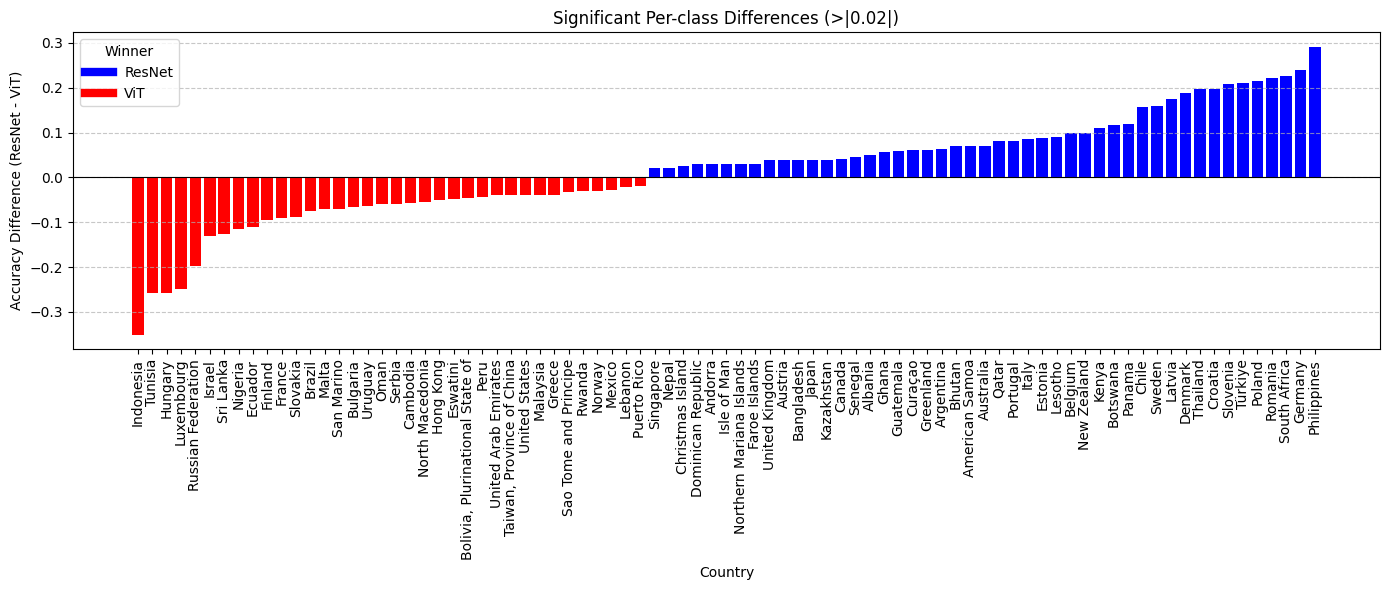

In [8]:
import matplotlib.pyplot as plt

clear_wins_sorted = clear_wins.sort_values("diff", ascending=True)

color_map = {"ResNet": "blue", "ViT": "red"}
colors = clear_wins_sorted["winner"].map(color_map)

plt.figure(figsize=(14,6))
plt.bar(clear_wins_sorted["ground_truth"], clear_wins_sorted["diff"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)  # zero line
plt.xticks(rotation=90)
plt.ylabel("Accuracy Difference (ResNet - ViT)")
plt.xlabel("Country")
plt.title(f"Significant Per-class Differences (>|{SIGNIFICANT_THRESHOLD}|)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], color=color_map[key], lw=6, label=key) for key in color_map]
plt.legend(handles=legend_elements, title="Winner")

plt.tight_layout()
plt.show()


### Per class standard deviation

To check which model predicts more consistent (lower = better)

->  ResNet has more confident and reliable predictions for each class (slight difference)

In [9]:
import numpy as np

resnet_std = per_class["resnet_acc"].std()
vit_std = per_class["vit_acc"].std()

print(f"ResNet per-class std: {resnet_std:.3f}")
print(f"ViT per-class std: {vit_std:.3f}")


ResNet per-class std: 0.209
ViT per-class std: 0.222


### Poor Performers

Check if poor performers are same for both models

In [10]:
from sklearn.metrics import f1_score

countries = df['ground_truth'].unique()

f1_resnet = {}
f1_vit = {}

for country in countries:
    y_true = (df['ground_truth'] == country).astype(int)
    
    y_pred_resnet = (df['pred_resnet'] == country).astype(int)
    y_pred_vit = (df['pred_vit'] == country).astype(int)
    
    f1_resnet[country] = f1_score(y_true, y_pred_resnet)
    f1_vit[country] = f1_score(y_true, y_pred_vit)

f1_df = pd.DataFrame({
    'F1_resnet': f1_resnet,
    'F1_vit': f1_vit
}).sort_values(by=['F1_resnet', 'F1_vit'])

poor_performers = f1_df[(f1_df['F1_resnet'] < 0.5) & (f1_df['F1_vit'] < 0.5)]

display(poor_performers)

,F1_resnet,F1_vit
Italy,0.198020,0.147651
Czechia,0.261905,0.284024
France,0.317308,0.298932
Lithuania,0.318841,0.326531
Slovakia,0.342246,0.377880
Spain,0.344086,0.340659
Croatia,0.400000,0.250000
Hungary,0.400000,0.421769
Portugal,0.407080,0.441860
Poland,0.411924,0.341137


### Identify outliers in terms of accuracy

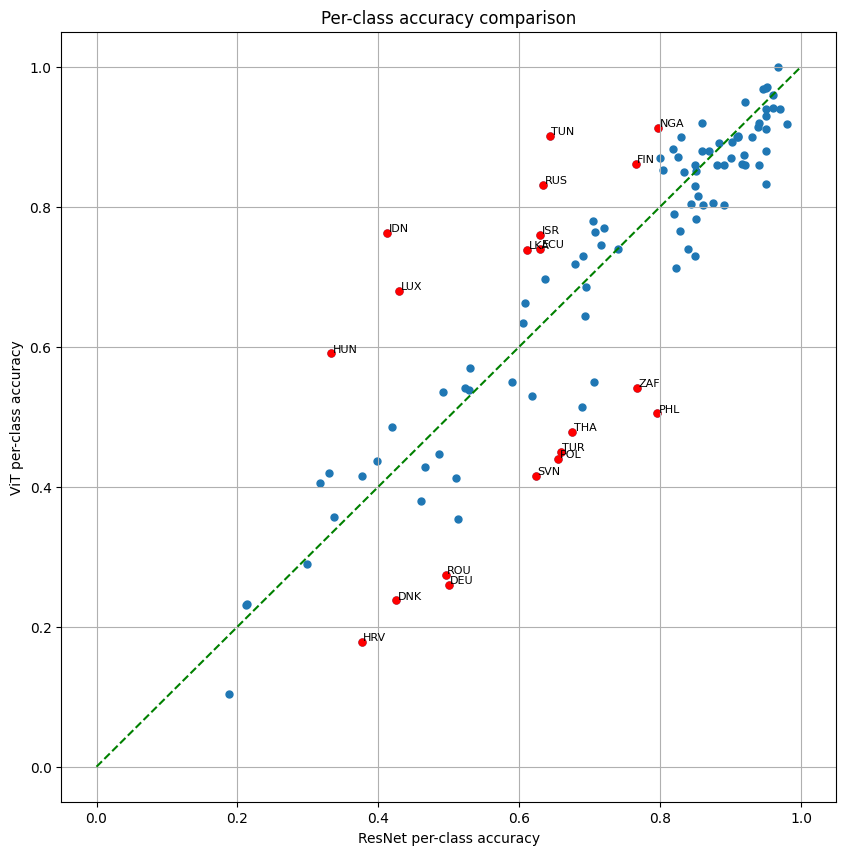

In [11]:
import matplotlib.pyplot as plt
import pycountry

top_vit = per_class.sort_values("diff", ascending=False).head(10)
top_resnet = per_class.sort_values("diff").head(10)

subset = pd.concat([top_vit, top_resnet])

plt.figure(figsize=(10,10))
plt.scatter(per_class["resnet_acc"], per_class["vit_acc"], s=25)
plt.scatter(subset["resnet_acc"], subset["vit_acc"], color="red", s=25)

for i, row in subset.iterrows():
    plt.text(row["resnet_acc"] + 0.002, row["vit_acc"] + 0.002, pycountry.countries.lookup(row["ground_truth"]).alpha_3, fontsize=8)

plt.plot([0,1], [0,1], "--", color="green")
plt.xlabel("ResNet per-class accuracy")
plt.ylabel("ViT per-class accuracy")
plt.title("Per-class accuracy comparison")
plt.grid(True)
plt.show()